##  Section 1: Imports and configuration

In [19]:
# ============================================================
# Section 1: Imports and configuration
# ============================================================
import os
import gc
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
from flax import linen as nn
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

NUM_CLASSES = 4
PARTICLE_NAMES = ['Pion', 'Kaon', 'Proton', 'Electron']
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

REAL_DATA_CSV = "/kaggle/input/rawreal-data-ao2d-lhc23zzh0544122/pid_features_real.csv"
MODEL_PATH = "/kaggle/input/models/robertforynski/fse-attention/jax/default/1/full_JAX_FSE_Attention.pkl"

# ── Cut toggles — must match the model used ───────────────────
# USE_DPG_CUTS = False  →  full_JAX_FSE_Attention.pkl
# USE_DPG_CUTS = True   →  full_DPG_JAX_FSE_Attention.pkl
USE_DPG_CUTS          = False
USE_TPC_SIGNAL_SANITY = True

# Exactly 25 features — matches the trained model's input dim.
# The 4 bayes_*_missing flags are always included (appended after base features).
TRAINING_FEATURES = [
    'pt', 'eta', 'phi',
    'tpc_signal', 'tpc_nsigma_pi', 'tpc_nsigma_ka', 'tpc_nsigma_pr', 'tpc_nsigma_el',
    'tof_beta', 'tof_nsigma_pi', 'tof_nsigma_ka', 'tof_nsigma_pr', 'tof_nsigma_el',
    'bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el',
    'dca_xy', 'dca_z',
    'has_tpc', 'has_tof',
    # These 4 missing-indicator columns must always be present (trained model expects them)
    'bayes_prob_pi_missing', 'bayes_prob_ka_missing',
    'bayes_prob_pr_missing', 'bayes_prob_el_missing',
]

DETECTOR_GROUPS = {
    'tpc':        ['tpc_signal', 'tpc_nsigma_pi', 'tpc_nsigma_ka', 'tpc_nsigma_pr', 'tpc_nsigma_el'],
    'tof':        ['tof_beta', 'tof_nsigma_pi', 'tof_nsigma_ka', 'tof_nsigma_pr', 'tof_nsigma_el'],
    'bayes':      ['bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el'],
    'kinematics': ['pt', 'eta', 'phi', 'dca_xy', 'dca_z'],
}

MOMENTUM_RANGES = {
    'mr_0_1':  {'name': '0–1 GeV/c (TPC Saturation)',  'min': 0.0,  'max': 1.0},
    'mr_1_3':  {'name': '1–3 GeV/c (TOF Transition)',  'min': 1.0,  'max': 3.0},
    'mr_full': {'name': 'Full Spectrum (0–∞ GeV/c)',   'min': 0.0,  'max': 100.0},
}

# DPG cuts — must match training exactly
TRACK_SELECTIONS = {
    'event':      {'vz_max': 10.0},
    'kinematics': {'eta_min': -0.8, 'eta_max': 0.8},
    'dca':        {'dca_xy_max': 0.105, 'dca_z_max': 0.12},
    'tpc':        {'tpc_clusters_min': 70},
    'its':        {'its_clusters_min': 3},
}
TRACK_QUALITY_FILTER = {
    'tpc_clusters_min': 70,
    'momentum_min': 0.01,
    'remove_negative_chi2': True,
}


## Section 2: FSE model

In [20]:
# ============================================================
# Section 2: FSE model — 4 groups to match trained weights
# ============================================================
class JAX_FSE_Attention(nn.Module):
    hidden_dim: int = 64
    num_heads: int = 4
    num_classes: int = 4
    dropout_rate: float = 0.3

    @nn.compact
    def __call__(self, x, group_mask, training=False):
        batch_size = x.shape[0]
        num_groups = group_mask.shape[1]          # will be 4
        feat_proj = nn.Dense(self.hidden_dim * num_groups)(x)
        feat_proj = feat_proj.reshape(batch_size, num_groups, self.hidden_dim)
        feat_proj = feat_proj * group_mask[:, :, None]
        attn_mask = group_mask[:, None, None, :]
        feat_attn = nn.MultiHeadDotProductAttention(num_heads=self.num_heads)(
            feat_proj, feat_proj, mask=attn_mask
        )
        feat_attn = nn.LayerNorm()(feat_attn)
        gates = nn.sigmoid(nn.Dense(self.hidden_dim)(feat_attn))
        feat_gated = feat_attn * gates
        denom = jnp.clip(jnp.sum(group_mask, axis=1, keepdims=True), 1.0)
        pooled = jnp.sum(feat_gated * group_mask[:, :, None], axis=1) / denom
        x = nn.Dense(128)(pooled)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)
        x = nn.Dense(64)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)
        return nn.Dense(self.num_classes)(x)
        

## Section 3: Load model

In [21]:
# ============================================================
# Section 3: Load model + verify inference contract
# ============================================================
with open(MODEL_PATH, "rb") as f:
    fse_obj = pickle.load(f)

print("Loaded object type:", type(fse_obj))
if isinstance(fse_obj, dict):
    print("Top-level keys:", list(fse_obj.keys()))

# ── Extract params ────────────────────────────────────────────
if 'params' not in fse_obj:
    raise KeyError(
        f"'params' key not found in pickle. Available keys: {list(fse_obj.keys())}"
    )
params = fse_obj['params']
print("✓ Model params loaded")

# ── Extract hyperparameters ───────────────────────────────────
hyper = fse_obj.get('hyperparameters', fse_obj.get('hparams', {}))
if not hyper:
    print("⚠ No hyperparameters found in pickle — using defaults")
    hyper = {'hidden_dim': 128, 'num_heads': 8, 'dropout_rate': 0.4}
print(f"✓ Hyperparameters: {hyper}")

# ── Extract and verify feature scalers ───────────────────────
feature_scalers = fse_obj.get('feature_scalers', {})
if not feature_scalers:
    print("⚠ WARNING: No feature_scalers found in pickle!")
    print("  This model was saved before the per-feature scaler contract.")
    print("  Scaling will be applied from scratch (may degrade accuracy).")
else:
    print(f"✓ Feature scalers loaded: {len(feature_scalers)} scalers")

# ── Verify feature contract ───────────────────────────────────
saved_features  = fse_obj.get('features', [])
saved_groups    = fse_obj.get('num_groups', None)
saved_skip      = fse_obj.get('skip_scaling', [])

print("\n" + "─"*60)
print("INFERENCE CONTRACT VERIFICATION")
print("─"*60)

# Feature list check
if saved_features:
    if saved_features == TRAINING_FEATURES:
        print(f"✓ Feature list matches: {len(saved_features)} features")
    else:
        mismatches = [(i, s, e) for i, (s, e) in enumerate(
            zip(saved_features, TRAINING_FEATURES)) if s != e]
        only_in_saved    = set(saved_features) - set(TRAINING_FEATURES)
        only_in_notebook = set(TRAINING_FEATURES) - set(saved_features)
        print(f"✗ Feature list MISMATCH!")
        if mismatches:
            print(f"  Position mismatches: {mismatches[:5]}")
        if only_in_saved:
            print(f"  Only in saved model: {only_in_saved}")
        if only_in_notebook:
            print(f"  Only in notebook:    {only_in_notebook}")
        raise ValueError("Feature contract mismatch — retrain or fix TRAINING_FEATURES")
else:
    print("⚠ No 'features' key in pickle — skipping feature list check")

# Group count check
if saved_groups is not None:
    if saved_groups == 4:
        print(f"✓ Group count matches: {saved_groups} groups")
    else:
        raise ValueError(
            f"Group count mismatch: saved={saved_groups}, expected=4"
        )
else:
    print("⚠ No 'num_groups' key in pickle — skipping group count check")

# Kernel shape check (hard verification against actual weights)
try:
    dense0_kernel = params['Dense_0']['kernel']
    n_features_from_kernel = dense0_kernel.shape[0]
    print(f"✓ Dense_0 kernel shape: {dense0_kernel.shape}")
    print(f"  → Model expects {n_features_from_kernel} input features")
    if n_features_from_kernel != len(TRAINING_FEATURES):
        raise ValueError(
            f"Kernel input dim={n_features_from_kernel} "
            f"!= TRAINING_FEATURES={len(TRAINING_FEATURES)}"
        )
    # FSE projects input to hidden_dim * num_groups
    n_proj = dense0_kernel.shape[1]
    hidden_dim  = hyper.get('hidden_dim', 128)
    num_groups  = n_proj // hidden_dim
    print(f"  → Projection output: {n_proj} = {hidden_dim} × {num_groups} groups")
    if num_groups != 4:
        raise ValueError(
            f"Group count from kernel: {num_groups}, expected 4"
        )
    print(f"✓ All contract checks passed")
except KeyError as e:
    print(f"⚠ Could not inspect kernel shape: {e}")

print("─"*60)

# ── Build model ───────────────────────────────────────────────
model = JAX_FSE_Attention(
    hidden_dim=hyper.get('hidden_dim', 128),
    num_heads=hyper.get('num_heads', 8),
    num_classes=NUM_CLASSES,
    dropout_rate=hyper.get('dropout_rate', 0.4),
)

@jax.jit
def fse_forward(params, x, group_mask):
    return model.apply({'params': params}, x, group_mask, training=False)

print("✓ Model built and forward function JIT-compiled")


Loaded object type: <class 'dict'>
Top-level keys: ['model_type', 'hyperparameters', 'train_losses', 'train_accuracies', 'val_accuracies', 'epoch_times', 'trained_epochs', 'total_train_time', 'avg_epoch_time', 'fastest_epoch_time', 'slowest_epoch_time', 'best_val_acc', 'train_acc', 'test_acc', 'train_probs', 'test_probs', 'y_pred_test', 'y_test', 'params', 'features', 'num_groups', 'group_names', 'feature_scalers', 'skip_scaling', 'detector_modes']
✓ Model params loaded
✓ Hyperparameters: {'hidden_dim': 128, 'num_heads': 8, 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'batch_size': 256, 'num_epochs': 100, 'patience': 30}
✓ Feature scalers loaded: 19 scalers

────────────────────────────────────────────────────────────
INFERENCE CONTRACT VERIFICATION
────────────────────────────────────────────────────────────
✓ Feature list matches: 25 features
✓ Group count matches: 4 groups
✓ Dense_0 kernel shape: (25, 512)
  → Model expects 25 input features
  → Projection output: 512 = 128 × 4 gro

## Section 4: Load real data

In [22]:
# ============================================================
# Section 4: Load real data + quality assessment
# ============================================================
print("\n" + "="*80)
print("REAL DATA LOADING & QUALITY ASSESSMENT")
print("="*80)

print(f"\nLoading real data: {REAL_DATA_CSV}...")
df_real = pd.read_csv(
    REAL_DATA_CSV,
    na_values=['-', 'nan', 'null', 'NaN', 'NULL', ''],
    keep_default_na=True,
    on_bad_lines='skip'
)
print("✓ Loaded successfully")

# ── Basic statistics ───────────────────────────────────
print("\n" + "─"*80)
print("BASIC DATA STATISTICS")
print("─"*80)
n_rows, n_cols = df_real.shape
mem_gb = df_real.memory_usage(deep=True).sum() / 1e9
print(f"\nShape: {df_real.shape}")
print(f"Total rows (tracks): {n_rows:,}")
print(f"Total columns: {n_cols}")
print(f"Memory usage: {mem_gb:.2f} GB")
print(f"\nColumns present ({n_cols}):  {', '.join(df_real.columns.tolist())}")

# ── Missing data ───────────────────────────────────────
print("\n" + "─"*80)
print("MISSING DATA ANALYSIS")
print("─"*80)
missing = df_real.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ["Column", "Missing Count"]
missing["Missing %"] = (missing["Missing Count"] / n_rows * 100).round(6)
if len(missing):
    print()
    print(missing.to_string(index=False))
else:
    print("\n✓ No missing values found")

# ── Track quality distribution ────────────────────────
print("\n" + "─"*80)
print("TRACK QUALITY DISTRIBUTION")
print("─"*80)

pt_min, pt_max   = df_real["pt"].min(),  df_real["pt"].max()
eta_min, eta_max = df_real["eta"].min(), df_real["eta"].max()
phi_min, phi_max = df_real["phi"].min(), df_real["phi"].max()
print(f"\nKinematic ranges:")
print(f"  pT: {pt_min:.4f} — {pt_max:.4f} GeV/c")
print(f"  η:  {eta_min:.4f} — {eta_max:.4f}")
print(f"  φ:  {phi_min:.4f} — {phi_max:.4f}")

# Cuts actually applied inside pidFeatureExtractor.cxx
# (configurable defaults: ptMin=0.1, ptMax=20.0, etaMin=-1.5, etaMax=1.5)
print(f"\nCuts applied in O2Physics extractor (pidFeatureExtractor.cxx):")
sel_pt  = ((df_real["pt"] >= 0.1) & (df_real["pt"] <= 20.0)).sum()
sel_eta = (df_real["eta"].between(-1.5, 1.5, inclusive="neither")).sum()
print(f"  pT ∈ [0.1, 20.0] GeV/c:     {sel_pt:,} ({sel_pt/n_rows*100:.1f}%)")
print(f"  η  ∈ [-1.5, 1.5]:            {sel_eta:,} ({sel_eta/n_rows*100:.1f}%)")

# DPG cuts NOT applied in extractor — shown for reference only
print(f"\nDPG cuts NOT applied in extractor (informational only):")
sel_eta_dpg = (df_real["eta"].between(-0.8, 0.8, inclusive="neither")).sum()
sel_dcaxy   = (df_real["dca_xy"].abs() < 0.105).sum() if "dca_xy" in df_real.columns else n_rows
sel_dcaz    = (df_real["dca_z"].abs()  < 0.12 ).sum() if "dca_z"  in df_real.columns else n_rows
tpc_cluster_col = next((c for c in ["tpc_nclusters", "tpc_clusters"] if c in df_real.columns), None)
sel_tpc = (df_real[tpc_cluster_col] >= 70).sum() if tpc_cluster_col else n_rows
print(f"  η  ∈ [-0.8, 0.8] (DPG):     {sel_eta_dpg:,} ({sel_eta_dpg/n_rows*100:.1f}%)")
print(f"  DCA_xy < 0.105 cm:           {sel_dcaxy:,} ({sel_dcaxy/n_rows*100:.1f}%)")
print(f"  DCA_z  < 0.12  cm:           {sel_dcaz:,} ({sel_dcaz/n_rows*100:.1f}%)")
print(f"  TPC clusters ≥ 70:           {sel_tpc:,} ({sel_tpc/n_rows*100:.1f}%)")

if "vz" in df_real.columns:
    vz_min, vz_max_val = df_real["vz"].min(), df_real["vz"].max()
    vz_ok = (df_real["vz"].abs() < 10.0).sum()
    print(f"\nCollision vertex distribution:")
    print(f"  vZ min: {vz_min:.2f} cm")
    print(f"  vZ max: {vz_max_val:.2f} cm")
    print(f"  vZ within ±10 cm:            {vz_ok:,} ({vz_ok/n_rows*100:.1f}%)")

print(f"\nDetector availability:")
has_tpc  = df_real["has_tpc"].fillna(0).astype(bool)
has_tof  = df_real["has_tof"].fillna(0).astype(bool)
tpc_only = ( has_tpc & ~has_tof).sum()
tof_only = (~has_tpc &  has_tof).sum()
both     = ( has_tpc &  has_tof).sum()
neither  = (~has_tpc & ~has_tof).sum()
print(f"  TPC only:                    {tpc_only:,} ({tpc_only/n_rows*100:.1f}%)")
print(f"  TOF only:                    {tof_only:,} ({tof_only/n_rows*100:.1f}%)")
print(f"  Both TPC+TOF:                {both:,} ({both/n_rows*100:.1f}%)")
print(f"  Neither:                     {neither:,} ({neither/n_rows*100:.1f}%)")

# ── Bayesian PID availability ─────────────────────────
print("\n" + "─"*80)
print("BAYESIAN PID AVAILABILITY")
print("─"*80)
bayes_cols  = ['bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el']
bayes_avail = (df_real[bayes_cols].fillna(0).sum(axis=1) > 0).sum()
bayes_miss  = n_rows - bayes_avail
print(f"\nBayesian PID available (sum > 0):    {bayes_avail:,} ({bayes_avail/n_rows*100:.1f}%)")
print(f"Bayesian PID missing:                 {bayes_miss:,} ({bayes_miss/n_rows*100:.1f}%)")
print(f"\nNote: Bayesian PID is computed on-the-fly in the extractor using TPC+TOF")
print(f"      n-sigma values with fixed priors (π=1.0, K=0.2, p=0.1, e=0.05).")
print(f"      Tracks without TOF rely on TPC-only Bayesian estimates.")
print("\n✓ DATA QUALITY ASSESSMENT COMPLETE")

# ============================================================
# Section 4b: Track selection cuts
# ============================================================

# Booleans controlling which cuts are applied — set in Section 1:
#   USE_DPG_CUTS        → full DPG track selections (eta, DCA, TPC clusters, etc.)
#   USE_TPC_SIGNAL_SANITY → TPC signal range [20, 500] a.u.
#
# Model must match cuts used during training:
#   USE_DPG_CUTS = False  →  full_JAX_FSE_Attention.pkl
#   USE_DPG_CUTS = True   →  full_DPG_JAX_FSE_Attention.pkl

n_before = len(df_real)
print(f"\nTrack selection cuts:")
print(f"  USE_DPG_CUTS:          {USE_DPG_CUTS}")
print(f"  USE_TPC_SIGNAL_SANITY: {USE_TPC_SIGNAL_SANITY}")
print(f"\nTracks before cuts: {n_before:,}")

if USE_DPG_CUTS:
    if TRACK_QUALITY_FILTER.get('remove_negative_chi2'):
        for chi2_col in ['tpc_chi2', 'track_chi2', 'chi2_per_ndf', 'chi2']:
            if chi2_col in df_real.columns:
                df_real = df_real[df_real[chi2_col] >= 0].copy()
                print(f"  ✓ Negative chi2 removed (column: '{chi2_col}')")
                break

    if 'pt' in df_real.columns:
        df_real = df_real[
            df_real['pt'] >= TRACK_QUALITY_FILTER['momentum_min']
        ].copy()

    if 'vz' in df_real.columns:
        df_real = df_real[
            df_real['vz'].abs() < TRACK_SELECTIONS['event']['vz_max']
        ].copy()

    if 'eta' in df_real.columns:
        df_real = df_real[
            df_real['eta'].between(
                TRACK_SELECTIONS['kinematics']['eta_min'],
                TRACK_SELECTIONS['kinematics']['eta_max'],
                inclusive='both'
            )
        ].copy()

    if 'dca_xy' in df_real.columns:
        df_real = df_real[
            df_real['dca_xy'].abs() < TRACK_SELECTIONS['dca']['dca_xy_max']
        ].copy()

    if 'dca_z' in df_real.columns:
        df_real = df_real[
            df_real['dca_z'].abs() < TRACK_SELECTIONS['dca']['dca_z_max']
        ].copy()

    tpc_cluster_col = next(
        (c for c in ['tpc_nclusters', 'tpc_clusters', 'tpc_ncls']
         if c in df_real.columns), None
    )
    if tpc_cluster_col:
        df_real = df_real[
            df_real[tpc_cluster_col] >= TRACK_SELECTIONS['tpc']['tpc_clusters_min']
        ].copy()

    its_cluster_col = next(
        (c for c in ['its_nclusters', 'its_clusters', 'its_ncls']
         if c in df_real.columns), None
    )
    if its_cluster_col:
        df_real = df_real[
            df_real[its_cluster_col] >= TRACK_SELECTIONS['its']['its_clusters_min']
        ].copy()

if USE_TPC_SIGNAL_SANITY:
    TPC_SIGNAL_MIN = 20.0
    TPC_SIGNAL_MAX = 500.0
    tpc_ok = (df_real['tpc_signal'] == 0) | (
        (df_real['tpc_signal'] >= TPC_SIGNAL_MIN) &
        (df_real['tpc_signal'] <= TPC_SIGNAL_MAX)
    )
    df_real = df_real[tpc_ok].copy()

n_after   = len(df_real)
n_removed = n_before - n_after
print(f"Tracks after  cuts: {n_after:,}  (removed {n_removed:,}, {n_removed/n_before*100:.1f}%)")




REAL DATA LOADING & QUALITY ASSESSMENT

Loading real data: /kaggle/input/rawreal-data-ao2d-lhc23zzh0544122/pid_features_real.csv...
✓ Loaded successfully

────────────────────────────────────────────────────────────────────────────────
BASIC DATA STATISTICS
────────────────────────────────────────────────────────────────────────────────

Shape: (7473918, 34)
Total rows (tracks): 7,473,918
Total columns: 34
Memory usage: 2.03 GB

Columns present (34):  event_id, track_id, px, py, pz, pt, p, eta, phi, theta, charge, track_type, tpc_signal, tpc_nsigma_pi, tpc_nsigma_ka, tpc_nsigma_pr, tpc_nsigma_el, tpc_nclusters, tpc_chi2, tof_beta, tof_mass, tof_nsigma_pi, tof_nsigma_ka, tof_nsigma_pr, tof_nsigma_el, bayes_prob_pi, bayes_prob_ka, bayes_prob_pr, bayes_prob_el, has_tpc, has_tof, dca_xy, dca_z, vz

────────────────────────────────────────────────────────────────────────────────
MISSING DATA ANALYSIS
────────────────────────────────────────────────────────────────────────────────

       C

## Section 5: Preprocess for inference

In [23]:
# ============================================================
# Section 5: Feature analysis + preprocessing
# ============================================================
print("\n" + "="*80)
print("FEATURE ANALYSIS FOR REAL DATA")
print("="*80)

df_proc = df_real.copy()
bayes_features = DETECTOR_GROUPS["bayes"]

# Imputation
for feat in DETECTOR_GROUPS["tof"]:
    if feat in df_proc.columns:
        df_proc[feat] = df_proc[feat].fillna(0.0 if feat == "tof_beta" else 999.0)
for feat in DETECTOR_GROUPS["tpc"]:
    if feat in df_proc.columns:
        df_proc[feat] = df_proc[feat].fillna(0.0 if feat == "tpc_signal" else 999.0)
for feat in bayes_features:
    miss_col = f"{feat}_missing"
    if feat in df_proc.columns:
        miss = (df_proc[feat] == 0) | (df_proc[feat].isna())
        df_proc[miss_col] = miss.astype("float32")
        df_proc.loc[miss, feat] = -0.25
    else:
        df_proc[feat]     = -0.25
        df_proc[miss_col] = 1.0
for feat in DETECTOR_GROUPS["kinematics"]:
    if feat in df_proc.columns:
        df_proc[feat] = df_proc[feat].fillna(df_proc[feat].median())
for col in ["has_tpc", "has_tof"]:
    df_proc[col] = df_proc[col].fillna(0.0) if col in df_proc.columns else 0.0

# Feature availability report
avail = [f for f in TRAINING_FEATURES if f in df_proc.columns]
print(f"\nAvailable training features: {len(avail)}/{len(TRAINING_FEATURES)}")
print(f"Features: {', '.join(avail)}")

missing_cols = [f for f in TRAINING_FEATURES if f not in df_proc.columns]
if missing_cols:
    raise ValueError(f"Missing features: {missing_cols}")

# ── PID detector feature distributions ───────────────────────
print("\n" + "─"*80)
print("PID Detector Feature Distributions")
print("─"*80)

tpc_valid = (df_proc["tpc_signal"] > 0)
print(f"\nTPC Signal (dE/dx):")
print(f"  Count (> 0):  {tpc_valid.sum():,} ({tpc_valid.mean()*100:.1f}%)")
print(f"  Mean:          {df_proc.loc[tpc_valid,'tpc_signal'].mean():.2f}")
print(f"  Std Dev:     {df_proc.loc[tpc_valid,'tpc_signal'].std():.2f}")
print(f"  Median:           {df_proc.loc[tpc_valid,'tpc_signal'].median():.2f}")

tof_valid = (df_proc["tof_beta"] > 0) & (df_proc["tof_beta"] < 2)
print(f"\nTOF Beta:")
print(f"  Count (0 < β < 2):  {tof_valid.sum():,} ({tof_valid.mean()*100:.1f}%)")
print(f"  Mean:                  {df_proc.loc[tof_valid,'tof_beta'].mean():.4f}")
print(f"  Std Dev:               {df_proc.loc[tof_valid,'tof_beta'].std():.4f}")
print(f"  Median:                {df_proc.loc[tof_valid,'tof_beta'].median():.4f}")

bayes_avail = (df_proc[bayes_features].replace(-0.25, np.nan).notna().all(axis=1)).sum()
print(f"\nBayesian Probabilities:")
print(f"  Available:    {bayes_avail:,} ({bayes_avail/len(df_proc)*100:.1f}%)")

# ── Build feature matrix and apply SAVED scalers ─────────────
X_real   = df_proc[TRAINING_FEATURES].values.astype('float32')
n_nan    = np.isnan(X_real).sum()
if n_nan:
    print(f"\n⚠ Found {n_nan} NaN values, replacing with 0")
    X_real = np.nan_to_num(X_real, nan=0.0)

X_scaled = X_real.copy()

SKIP_SCALING = {'has_tpc', 'has_tof'} | {f"{f}_missing" for f in bayes_features}

if feature_scalers:
    # ── USE SAVED SCALERS from training (correct path) ───────
    print("\nApplying saved training scalers...")
    n_applied = 0
    for i, feat in enumerate(TRAINING_FEATURES):
        if feat in SKIP_SCALING:
            continue
        if feat not in feature_scalers:
            print(f"  ⚠ No scaler for '{feat}' — leaving unscaled")
            continue

        scaler = feature_scalers[feat]
        col    = X_real[:, i]

        if feat in bayes_features:
            # Sentinel -0.25 stays untouched; scale only real values
            real_mask = col != -0.25
            if real_mask.sum() > 0:
                X_scaled[real_mask, i] = scaler.transform(
                    col[real_mask].reshape(-1, 1)
                ).reshape(-1)
        else:
            X_scaled[:, i] = scaler.transform(
                col.reshape(-1, 1)
            ).reshape(-1)
        n_applied += 1

    print(f"✓ Applied {n_applied} saved scalers")

else:
    # ── FALLBACK: fit fresh scalers on real data (last resort) ─
    print("\n⚠ WARNING: Fitting fresh scalers on real data — accuracy may be reduced")
    print("  Retrain with the updated FSE-Detector-Aware-PID notebook to fix this.")
    fresh_scaler = StandardScaler()
    for i, feat in enumerate(TRAINING_FEATURES):
        if feat in SKIP_SCALING:
            continue
        col = X_real[:, i]
        if feat in bayes_features:
            real_mask = col != -0.25
            if real_mask.sum() > 0:
                fresh_scaler.fit(col[real_mask].reshape(-1, 1))
                X_scaled[real_mask, i] = fresh_scaler.transform(
                    col[real_mask].reshape(-1, 1)
                ).reshape(-1)
        else:
            fresh_scaler.fit(col.reshape(-1, 1))
            X_scaled[:, i] = fresh_scaler.transform(col.reshape(-1, 1)).reshape(-1)

print(f"\n✓ Feature matrix shape: {X_scaled.shape}")

bayes_present = (
    df_proc[['bayes_prob_pi_missing', 'bayes_prob_ka_missing',
             'bayes_prob_pr_missing', 'bayes_prob_el_missing']]
    .values.mean(axis=1) < 1.0
).astype("float32")

group_masks = np.stack([
    df_proc["has_tpc"].values.astype("float32"),
    df_proc["has_tof"].values.astype("float32"),
    bayes_present,
    np.ones(len(df_proc), dtype="float32"),
], axis=1)

print(f"\nGroup mask: {group_masks.shape}")
assert X_scaled.shape[1] == 25, f"Expected 25 features, got {X_scaled.shape[1]}"
assert group_masks.shape[1] == 4, f"Expected 4 groups, got {group_masks.shape[1]}"



FEATURE ANALYSIS FOR REAL DATA

Available training features: 25/25
Features: pt, eta, phi, tpc_signal, tpc_nsigma_pi, tpc_nsigma_ka, tpc_nsigma_pr, tpc_nsigma_el, tof_beta, tof_nsigma_pi, tof_nsigma_ka, tof_nsigma_pr, tof_nsigma_el, bayes_prob_pi, bayes_prob_ka, bayes_prob_pr, bayes_prob_el, dca_xy, dca_z, has_tpc, has_tof, bayes_prob_pi_missing, bayes_prob_ka_missing, bayes_prob_pr_missing, bayes_prob_el_missing

────────────────────────────────────────────────────────────────────────────────
PID Detector Feature Distributions
────────────────────────────────────────────────────────────────────────────────

TPC Signal (dE/dx):
  Count (> 0):  7,466,518 (100.0%)
  Mean:          59.41
  Std Dev:     18.55
  Median:           55.92

TOF Beta:
  Count (0 < β < 2):  2,471,108 (33.1%)
  Mean:                  0.9050
  Std Dev:               0.1852
  Median:                0.9765

Bayesian Probabilities:
  Available:    2,474,189 (33.1%)

Applying saved training scalers...
✓ Applied 19 sav

## Section 6: Inference

In [24]:
# ============================================================
# Section 6: Inference
# ============================================================
print("\n" + "="*80)
print("FSE ATTENTION INFERENCE ON REAL DATA")
print("="*80)

batch_size = 4096
n          = len(df_proc)
y_pred     = np.empty(n, dtype=np.int32)
y_proba    = np.empty((n, NUM_CLASSES), dtype=np.float32)
confidence = np.empty(n, dtype=np.float32)

print("\nStep 1: Running inference...")
for start in range(0, n, batch_size):
    end    = min(start + batch_size, n)
    logits = fse_forward(
        params,
        jnp.array(X_scaled[start:end]),
        jnp.array(group_masks[start:end])
    )
    probs = np.array(jax.nn.softmax(logits, axis=-1))
    y_proba[start:end]    = probs
    y_pred[start:end]     = probs.argmax(axis=1)
    confidence[start:end] = probs.max(axis=1)

df_proc["ml_pred_class"] = y_pred
df_proc["ml_prob_pi"]    = y_proba[:, 0]
df_proc["ml_prob_ka"]    = y_proba[:, 1]
df_proc["ml_prob_pr"]    = y_proba[:, 2]
df_proc["ml_prob_el"]    = y_proba[:, 3]
df_proc["ml_confidence"] = confidence

preds_made = n
print(f"✓ Inference complete: {preds_made:,} predictions")
print(f"\nStep 2: Combining predictions...")
print(f"Predictions made: {preds_made:,} / {n:,} ({preds_made/n*100:.1f}%)")
print(f"\n✓ Added ML predictions to dataframe")



FSE ATTENTION INFERENCE ON REAL DATA

Step 1: Running inference...
✓ Inference complete: 7,466,573 predictions

Step 2: Combining predictions...
Predictions made: 7,466,573 / 7,466,573 (100.0%)

✓ Added ML predictions to dataframe


## Section 7: Save output

In [25]:
# ============================================================
# Section 7: Save output
# ============================================================
OUTPUT_CSV = "ml_predictions_real_data_FSE.csv"
df_proc.to_csv(OUTPUT_CSV, index=False)
size_gb = os.path.getsize(OUTPUT_CSV) / 1e9

print("\n" + "─"*80)
print("OUTPUT FILE SUMMARY")
print("─"*80)
print(f"{OUTPUT_CSV} (~{size_gb:.1f} GB)")
print(f"\nFile contains:")
print(f"  • Original features (pt, eta, phi, tpc_signal, tof_beta, etc.)")
print(f"  • ML predictions (ml_pred_class: 0=π, 1=K, 2=p, 3=e)")
print(f"  • ML probabilities (ml_prob_pi, ml_prob_ka, ml_prob_pr, ml_prob_el)")
print(f"  • Confidence scores (ml_confidence: 0-1)")



────────────────────────────────────────────────────────────────────────────────
OUTPUT FILE SUMMARY
────────────────────────────────────────────────────────────────────────────────
ml_predictions_real_data_FSE.csv (~2.3 GB)

File contains:
  • Original features (pt, eta, phi, tpc_signal, tof_beta, etc.)
  • ML predictions (ml_pred_class: 0=π, 1=K, 2=p, 3=e)
  • ML probabilities (ml_prob_pi, ml_prob_ka, ml_prob_pr, ml_prob_el)
  • Confidence scores (ml_confidence: 0-1)


## Section 8: Basic validation

In [26]:
# ============================================================
# Section 8: Physics validation
# ============================================================
print("\n" + "="*80)
print("PHYSICS VALIDATION")
print("="*80)

# ── TPC dE/dx ordering ────────────────────────────────
print("\n" + "─"*80)
print("TPC dE/dx ORDERING VALIDATION")
print("─"*80)
print("\nExpected: π < K < p (by mass dependence)")

tpc_all = df_proc["tpc_signal"]
print(f"\nRaw TPC signal statistics (ALL tracks):")
print(f"  Min:       {tpc_all.min():.2f}")
print(f"  Max:       {tpc_all.max():.2f}")
print(f"  Mean:      {tpc_all.mean():.2f}")
print(f"  Median:    {tpc_all.median():.2f}")
print(f"  Std Dev:   {tpc_all.std():.2f}")

# tpc_valid_global and USE_TPC_SIGNAL_SANITY are set in Section 4b
if USE_TPC_SIGNAL_SANITY:
    tpc_valid_global = (
        (df_proc["tpc_signal"] > TPC_SIGNAL_MIN) &
        (df_proc["tpc_signal"] < TPC_SIGNAL_MAX)
    )
    n_outliers = (~tpc_valid_global).sum()
    print(f"\nTPC signal sanity [{TPC_SIGNAL_MIN}, {TPC_SIGNAL_MAX}] a.u.: ENABLED")
    print(f"  Outliers excluded: {n_outliers:,} ({n_outliers/len(df_proc)*100:.2f}%)")
else:
    tpc_valid_global = (df_proc["tpc_signal"] > 0)
    print(f"\nTPC signal sanity: DISABLED — using tpc_signal > 0 only")

# ── Per-particle stats: raw vs cleaned ───────────────
print(f"\n{'Particle':<16}{'Raw Mean':>12}{'Raw N':>10}"
      f"{'Clean Mean':>13}{'Clean N':>10}{'% kept':>8}")
print("-"*70)

tpc_means_raw   = {}
tpc_means_clean = {}

for i, name in enumerate(PARTICLE_NAMES):
    pred_mask  = (df_proc["ml_pred_class"] == i)
    raw_mask   = pred_mask & (df_proc["tpc_signal"] > 0)
    clean_mask = pred_mask & tpc_valid_global

    raw_mean   = df_proc.loc[raw_mask,   "tpc_signal"].mean() if raw_mask.sum()   > 0 else float("nan")
    clean_mean = df_proc.loc[clean_mask, "tpc_signal"].mean() if clean_mask.sum() > 0 else float("nan")
    raw_n      = raw_mask.sum()
    clean_n    = clean_mask.sum()
    pct_kept   = (clean_n / raw_n * 100) if raw_n > 0 else 0.0

    tpc_means_raw[name]   = raw_mean
    tpc_means_clean[name] = clean_mean

    print(f"{name:<16}{raw_mean:>12.2f}{raw_n:>10,}"
          f"{clean_mean:>13.2f}{clean_n:>10,}{pct_kept:>7.1f}%")

print(f"\nVerification:")
pi_k_clean = tpc_means_clean['Pion']  < tpc_means_clean['Kaon']
k_p_clean  = tpc_means_clean['Kaon'] < tpc_means_clean['Proton']
print(f"  π < K: {'✓' if pi_k_clean else '✗'}  "
      f"({tpc_means_clean['Pion']:.2f} < {tpc_means_clean['Kaon']:.2f})")
print(f"  K < p: {'✓' if k_p_clean  else '✗'}  "
      f"({tpc_means_clean['Kaon']:.2f} < {tpc_means_clean['Proton']:.2f})")

print(f"\nMedian-based check (most robust):")
tpc_medians = {}
for i, name in enumerate(PARTICLE_NAMES):
    mask = (df_proc["ml_pred_class"] == i) & tpc_valid_global
    med  = df_proc.loc[mask, "tpc_signal"].median() if mask.sum() > 0 else float("nan")
    tpc_medians[name] = med
    print(f"  {name:<12}: median dE/dx = {med:.2f}")

pi_k_med = tpc_medians['Pion']  < tpc_medians['Kaon']
k_p_med  = tpc_medians['Kaon'] < tpc_medians['Proton']
print(f"\n  π < K: {'✓' if pi_k_med else '✗'}  "
      f"({tpc_medians['Pion']:.2f} < {tpc_medians['Kaon']:.2f})")
print(f"  K < p: {'✓' if k_p_med  else '✗'}  "
      f"({tpc_medians['Kaon']:.2f} < {tpc_medians['Proton']:.2f})")

print(f"\nOutlier breakdown per predicted particle:")
print(f"{'Particle':<16}{'Outlier N':>12}{'Outlier %':>12}{'Max value':>14}")
print("-"*55)
for i, name in enumerate(PARTICLE_NAMES):
    pred_mask    = (df_proc["ml_pred_class"] == i)
    outlier_mask = pred_mask & (~tpc_valid_global) & (df_proc["tpc_signal"] > 0)
    n_out        = outlier_mask.sum()
    n_pred       = pred_mask.sum()
    max_val      = df_proc.loc[outlier_mask, "tpc_signal"].max() if n_out > 0 else 0
    print(f"{name:<16}{n_out:>12,}{n_out/max(n_pred,1)*100:>11.2f}%{max_val:>14.1f}")

if pi_k_med and k_p_med:
    print(f"\n✓ TPC ordering CORRECT on physical tracks")
else:
    print(f"\n✗ TPC ordering issue persists even after outlier removal")
    print(f"  This may indicate a genuine model classification problem")

# ── TOF β ordering ────────────────────────────────────
print("\n" + "─"*80)
print("TOF β ORDERING VALIDATION")
print("─"*80)
print("\nExpected: π > K > p (lighter particles are faster)")
print(f"\n{'Particle':<20}{'Mean β':>10}")
print("-"*40)
tof_means = {}
for i, name in enumerate(PARTICLE_NAMES):
    mask     = (df_proc["ml_pred_class"] == i) & (df_proc["tof_beta"] > 0) & (df_proc["tof_beta"] < 2)
    mean_val = df_proc.loc[mask, "tof_beta"].mean() if mask.sum() > 0 else float("nan")
    tof_means[name] = mean_val
    print(f"{name:<20}{mean_val:>10.4f}")

print(f"\nVerification:")
pi_k = tof_means['Pion']  > tof_means['Kaon']
k_p  = tof_means['Kaon'] > tof_means['Proton']
print(f"  π > K: {'✓' if pi_k else '✗'} ({tof_means['Pion']:.4f} > {tof_means['Kaon']:.4f})")
print(f"  K > p: {'✓' if k_p  else '✗'} ({tof_means['Kaon']:.4f} > {tof_means['Proton']:.4f})")

# ── Confidence statistics ─────────────────────────────
print("\n" + "─"*80)
print("ML CONFIDENCE STATISTICS")
print("─"*80)
conf = df_proc["ml_confidence"]
print(f"\nMean confidence:     {conf.mean():.4f}")
print(f"Median confidence:   {conf.median():.4f}")
print(f"Std Dev:             {conf.std():.4f}")
print(f"\nConfidence distribution:")
for thr in [0.99, 0.95, 0.90, 0.80]:
    cnt = (conf > thr).sum()
    print(f"  > {thr:.2f}:   {cnt:,} ({cnt/n*100:.1f}%)")



PHYSICS VALIDATION

────────────────────────────────────────────────────────────────────────────────
TPC dE/dx ORDERING VALIDATION
────────────────────────────────────────────────────────────────────────────────

Expected: π < K < p (by mass dependence)

Raw TPC signal statistics (ALL tracks):
  Min:       0.00
  Max:       499.94
  Mean:      59.41
  Median:    55.92
  Std Dev:   18.55

TPC signal sanity [20.0, 500.0] a.u.: ENABLED
  Outliers excluded: 55 (0.00%)

Particle            Raw Mean     Raw N   Clean Mean   Clean N  % kept
----------------------------------------------------------------------
Pion                   57.65 6,704,276        57.65 6,704,276  100.0%
Kaon                   66.15   533,341        66.15   533,341  100.0%
Proton                 95.33   183,095        95.33   183,095  100.0%
Electron               94.97    45,806        94.97    45,806  100.0%

Verification:
  π < K: ✓  (57.65 < 66.15)
  K < p: ✓  (66.15 < 95.33)

Median-based check (most robust):
  

## Section 9: pT bin validation

In [27]:
# ============================================================
# Section 9: pT bins + Bayesian agreement
# ============================================================

# ── Fractions vs pT ───────────────────────────────────
print("\n" + "─"*80)
print("ML PRODUCTION FRACTIONS vs pT")
print("─"*80)

pt_bins   = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 100.0]
pt_labels = ["0-0.5", "0.5-1.0", "1.0-1.5", "1.5-2.0", "2.0-3.0", "3.0-5.0", "5.0-10.0", ">10"]
df_proc["pt_bin"] = pd.cut(df_proc["pt"], bins=pt_bins, labels=pt_labels, include_lowest=True)

header = f"{'pT Bin (GeV/c)':<20}{'Pion':>10}{'Kaon':>10}{'Proton':>10}{'Electron':>12}{'Total':>10}"
print(f"\n{header}")
print("-"*75)
for label in pt_labels:
    sub = df_proc[df_proc["pt_bin"] == label]
    if len(sub) == 0:
        continue
    fracs = [(sub["ml_pred_class"] == i).mean() * 100 for i in range(NUM_CLASSES)]
    print(f"{label:<20}{fracs[0]:>9.1f}%{fracs[1]:>9.1f}%{fracs[2]:>9.1f}%{fracs[3]:>11.1f}%{len(sub):>10,}")

# ── ML vs Bayesian agreement ──────────────────────────
print("\n" + "─"*80)
print("ML vs BAYESIAN PID AGREEMENT")
print("─"*80)

bayes_map = {0: 'bayes_prob_pi', 1: 'bayes_prob_ka', 2: 'bayes_prob_pr', 3: 'bayes_prob_el'}
bayes_mask = (df_proc[list(bayes_map.values())].replace(-0.25, np.nan).notna().all(axis=1))
df_bayes = df_proc[bayes_mask].copy()
df_bayes["bayes_pred"] = df_bayes[[bayes_map[i] for i in range(4)]].values.argmax(axis=1)

n_bayes = len(df_bayes)
overall_agree = (df_bayes["ml_pred_class"] == df_bayes["bayes_pred"]).mean() * 100
print(f"\nTracks with ML predictions AND Bayesian data: {n_bayes:,}")
print(f"\nOverall agreement: {overall_agree:.2f}%")
print(f"\n{'Particle':<16}{'Agreement':>12}")
print("-"*30)
for i, name in enumerate(PARTICLE_NAMES):
    mask = df_bayes["ml_pred_class"] == i
    if mask.sum() > 0:
        agree = (df_bayes.loc[mask, "bayes_pred"] == i).mean() * 100
        print(f"{name:<16}{agree:>11.1f}%")

# ── Overall summary ───────────────────────────────────
print("\n" + "─"*80)
print("OVERALL SUMMARY")
print("─"*80)
print(f"\n{'Particle':>10}{'Count':>10}{'Fraction':>10}{'<pT>':>8}{'<η>':>8}{'Confidence':>12}")
for i, name in enumerate(PARTICLE_NAMES):
    mask = df_proc["ml_pred_class"] == i
    cnt  = mask.sum()
    frac = cnt / n * 100
    mean_pt   = df_proc.loc[mask, "pt"].mean()
    mean_eta  = df_proc.loc[mask, "eta"].mean()
    mean_conf = df_proc.loc[mask, "ml_confidence"].mean()
    print(f"{name:>10}{cnt:>10,}{frac:>9.1f}%{mean_pt:>8.3f}{mean_eta:>8.3f}{mean_conf:>12.4f}")



────────────────────────────────────────────────────────────────────────────────
ML PRODUCTION FRACTIONS vs pT
────────────────────────────────────────────────────────────────────────────────

pT Bin (GeV/c)            Pion      Kaon    Proton    Electron     Total
---------------------------------------------------------------------------
0-0.5                    96.8%      1.6%      0.4%        1.2% 3,283,329
0.5-1.0                  94.0%      3.9%      1.8%        0.3% 2,541,604
1.0-1.5                  83.3%     12.5%      4.2%        0.0%   983,464
1.5-2.0                  56.1%     35.5%      8.3%        0.0%   389,336
2.0-3.0                  38.5%     47.1%     14.4%        0.0%   218,129
3.0-5.0                  25.4%     36.2%     38.4%        0.0%    46,024
5.0-10.0                 38.9%     38.0%     23.1%        0.0%     4,366
>10                     100.0%      0.0%      0.0%        0.0%       321

────────────────────────────────────────────────────────────────────────

## Section 10: Plots

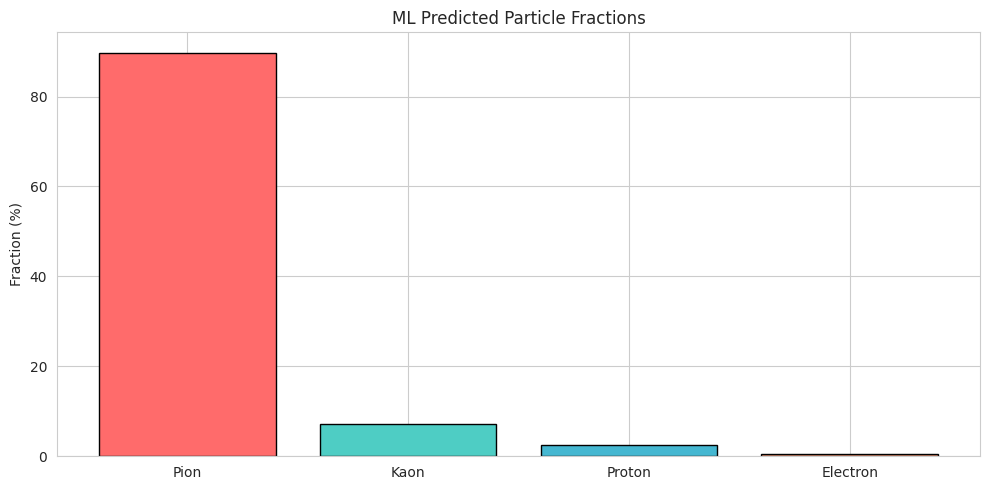

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
fractions = [(df_proc["ml_pred_class"] == i).mean() * 100 for i in range(4)]
ax.bar(PARTICLE_NAMES, fractions, color=COLORS, edgecolor="black")
ax.set_ylabel("Fraction (%)")
ax.set_title("ML Predicted Particle Fractions")
plt.tight_layout()
plt.savefig("plot_predicted_fractions.png", dpi=150, bbox_inches="tight")
plt.show()


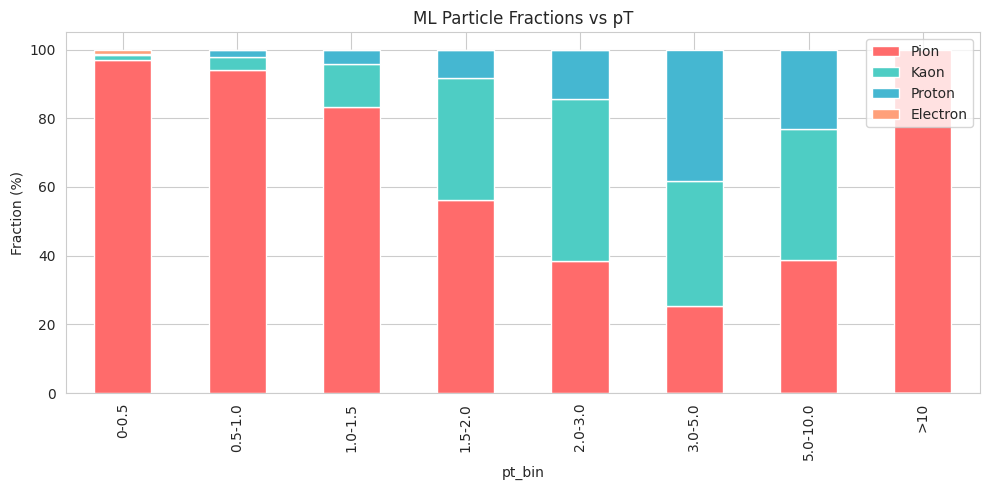

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
rows = []
for label in pt_labels:
    sub = df_proc[df_proc["pt_bin"] == label]
    if len(sub) == 0:
        continue
    rows.append({
        "pt_bin": label,
        "Pion": (sub["ml_pred_class"] == 0).mean() * 100,
        "Kaon": (sub["ml_pred_class"] == 1).mean() * 100,
        "Proton": (sub["ml_pred_class"] == 2).mean() * 100,
        "Electron": (sub["ml_pred_class"] == 3).mean() * 100,
    })

plot_frac = pd.DataFrame(rows)
plot_frac.set_index("pt_bin")[PARTICLE_NAMES].plot(kind="bar", stacked=True, ax=ax, color=COLORS)
ax.set_ylabel("Fraction (%)")
ax.set_title("ML Particle Fractions vs pT")
plt.tight_layout()
plt.savefig("plot_fractions_vs_pt.png", dpi=150, bbox_inches="tight")
plt.show()


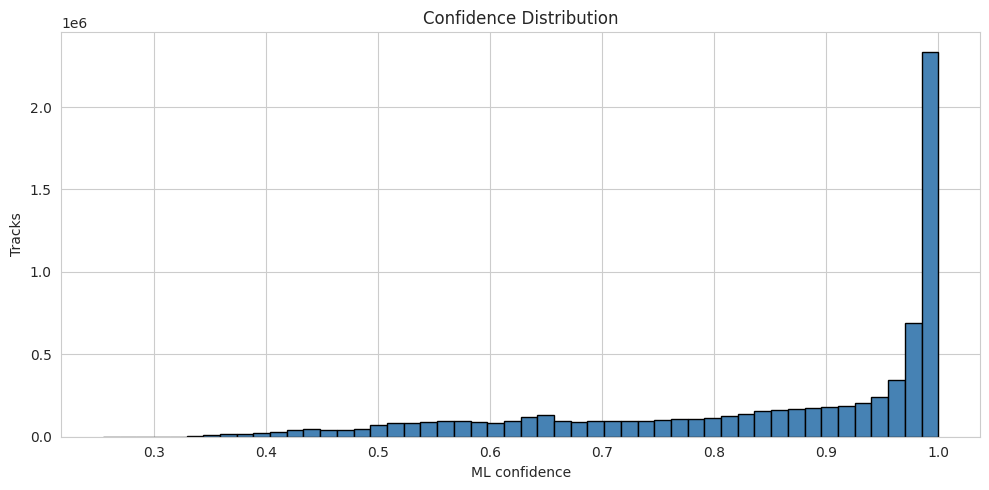

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_proc["ml_confidence"], bins=50, color="steelblue", edgecolor="black")
ax.set_xlabel("ML confidence")
ax.set_ylabel("Tracks")
ax.set_title("Confidence Distribution")
plt.tight_layout()
plt.savefig("plot_confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
